In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pdb
from einops import rearrange
from sklearn.metrics import accuracy_score
# ignore all warning
import warnings
warnings.filterwarnings('ignore')

In [2]:
# customized library
# 从自定义模块导入功能函数

# 导入DRCDT和HOG特征提取函数
from rcdt_hog_feature_extraction import get_drcdt_feature_sets
# 导入NS分类器类
from NS_classifier_patch import NS
# 导入文件处理和数据集加载工具函数
from utility import get_files_from_folder, get_each_subject_yale_dataset, get_folder_from_path

In [3]:
# 图像文件扩展名 - 指定使用的图像格式为PGM格式
IMG_EXT = '.pgm' 
# 输入数据路径 - 指向Yale人脸数据集裁剪版本的目录路径
INPUT_DATA_PATH = './CroppedYale/'

In [4]:
# perpare to load the data
# 获取输入路径下的所有文件夹列表 - 用于遍历Yale数据集中的每个受试者文件夹
full_folder = get_folder_from_path(INPUT_DATA_PATH)

In [5]:
# load data and labels
# 加载数据和标签

# 存储所有受试者的图像数据
dataX_all_subjects = []
# 存储所有受试者的标签数据
dataY_all_subjects = []

# 遍历每个受试者文件夹
for each_folder_in_full_folder in full_folder:
    # 构建当前受试者文件夹的完整路径
    path_to_this_folder = INPUT_DATA_PATH + each_folder_in_full_folder + '/'
    # 获取该文件夹中所有PGM图像文件的列表
    imgs_in_this_folder_list = get_files_from_folder(path_to_this_folder, IMG_EXT)
    # 加载当前受试者的数据集和标签，LOG_IMG=False表示不记录图像日志
    dataX_this_folder, dataY_this_folder = get_each_subject_yale_dataset(path_to_this_folder, imgs_in_this_folder_list, IMG_EXT, LOG_IMG = False)

    # 将当前受试者的数据和标签添加到总列表中
    dataX_all_subjects.append(dataX_this_folder)
    dataY_all_subjects.append(dataY_this_folder)

# 将列表转换为numpy数组以便后续处理
dataX_all_subjects = np.asarray(dataX_all_subjects)
dataY_all_subjects = np.asarray(dataY_all_subjects)

In [6]:
# There 38 subjects
# 输出图像数据的维度
print(dataX_all_subjects.shape)
# 输出标签数据的维度
print(dataY_all_subjects.shape)

(38,)
(38,)


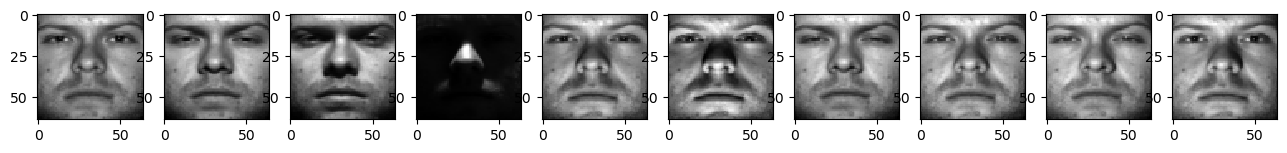

In [7]:
# visulize some face data for sanity check
# 创建图像显示画布：1行10列的子图布局，图像尺寸为16x16英寸
_, plt_axis_test = plt.subplots(1, 10, figsize=(16,16))

# 将子图轴对象展平为一维数组，便于循环访问
plt_axis_test = plt_axis_test.ravel()

# 循环显示前10张图像
for imyplotN in range(10):
    # 显示第0个受试者的第imyplotN张图像
    # 将图像数据重塑为64x64像素，使用灰度色彩映射
    plt_axis_test[imyplotN].imshow(dataX_all_subjects[0][imyplotN].reshape([64, 64]), cmap='gray')

In [8]:
# Extract D-RCDT feature sets
# setup for the parameters
# training set index is 0
# testing set index is from 1-4
#提取D-RCDT特征集
#参数设置
#训练集索引为0
#测试集索引为1-4
TRAIN_SUBSET = [0] # Training set is 0,
TEST_SUBSET = [4] #  Testing set is 1, 2, 3, 4
STEP_SIZE = 4 # cell size
OVERLAP_SIZE = 1 # overlap size
PROJECT_N = 4 # number of projections
N_SUBJECTS = 38 # number of classes

# 初始化训练和测试数据集列表
X_train = [] # 原始训练图像
X_hog_train = [] # HOG特征训练集
X_rcdt_train = [] # RCDT特征训练集
Y_train = [] # 训练标签

X_test = [] # 原始测试图像
X_hog_test = [] # HOG特征测试集
X_rcdt_test = [] # RCDT特征测试集
Y_test = [] # 测试标签

# 小样本学习设置：0->使用所有训练样本，1->仅使用一个训练样本
FEW_SHOT = 1

subject_ID = 0 # 受试者ID计数器
# 遍历每个受试者的数据和标签
for each_subject_X, each_subject_Y in zip(dataX_all_subjects, dataY_all_subjects):
    #print(each_subject_X.shape, each_subject_Y.shape)
    
    # 构建训练数据集
    for train_subset_index in TRAIN_SUBSET:
        # 获取当前受试者指定子集的训练图像
        X_train_each_subject_temp = each_subject_X[each_subject_Y==train_subset_index]
        
        # 如果启用小样本学习，随机选择一张图像
        if FEW_SHOT == 1:
            np.random.seed(1234) # 设置随机种子保证可重复性
            rand_index = np.random.choice(range(len(X_train_each_subject_temp)), 1, replace=False) # 随机选择一张图像
            X_train_each_subject_temp = X_train_each_subject_temp[rand_index]

        # 处理每个训练图像
        for X_train_per_img_per_subject in X_train_each_subject_temp:
            # 提取D-RCDT特征（忽略前三个返回值，只取rcdt_temp）
            _, _, _, rcdt_temp = get_drcdt_feature_sets(X_train_per_img_per_subject.reshape([64,64])*255, 
                                                       step_size=STEP_SIZE, 
                                                       overlap_size=OVERLAP_SIZE, 
                                                       proj_n=PROJECT_N)

            # 将数据添加到训练集
            X_train.append(X_train_per_img_per_subject.reshape([64,64]))
            X_rcdt_train.append(rcdt_temp)
            Y_train.append(subject_ID) # 添加受试者ID作为标签

    # 构建测试数据集
    for test_subset_index in TEST_SUBSET:
        # 获取当前受试者指定子集的测试图像
        X_test_each_subject_temp = each_subject_X[each_subject_Y==test_subset_index]
        
        # 处理每个测试图像
        for X_test_per_img_per_subject in X_test_each_subject_temp:
            # 提取D-RCDT特征
            _, _, _, rcdt_temp = get_drcdt_feature_sets(X_test_per_img_per_subject.reshape([64,64])*255, 
                                                       step_size=STEP_SIZE, 
                                                       overlap_size=OVERLAP_SIZE, 
                                                       proj_n=PROJECT_N)
            # 将数据添加到测试集
            X_test.append(X_test_per_img_per_subject.reshape([64,64]))
            X_rcdt_test.append(rcdt_temp)
            Y_test.append(subject_ID) # 添加受试者ID作为标签
    # 更新受试者ID
    subject_ID = subject_ID + 1 

In [9]:
# transform to Numpy asarray
# 将训练数据集列表转换为numpy数组，便于后续的数值计算和机器学习处理
X_train = np.asarray(X_train)  # 原始训练图像数据，形状为(样本数, 64, 64)
X_hog_train = np.asarray(X_hog_train)  # HOG特征训练数据
X_rcdt_train = np.asarray(X_rcdt_train)  # RCDT特征训练数据
Y_train = np.asarray(Y_train)  # 训练标签，形状为(样本数,)

# 将测试数据集列表转换为numpy数组
X_test = np.asarray(X_test)  # 原始测试图像数据，形状为(样本数, 64, 64)
X_hog_test = np.asarray(X_hog_test)  # HOG特征测试数据
X_rcdt_test = np.asarray(X_rcdt_test)  # RCDT特征测试数据
Y_test = np.asarray(Y_test)  # 测试标签，形状为(样本数,)

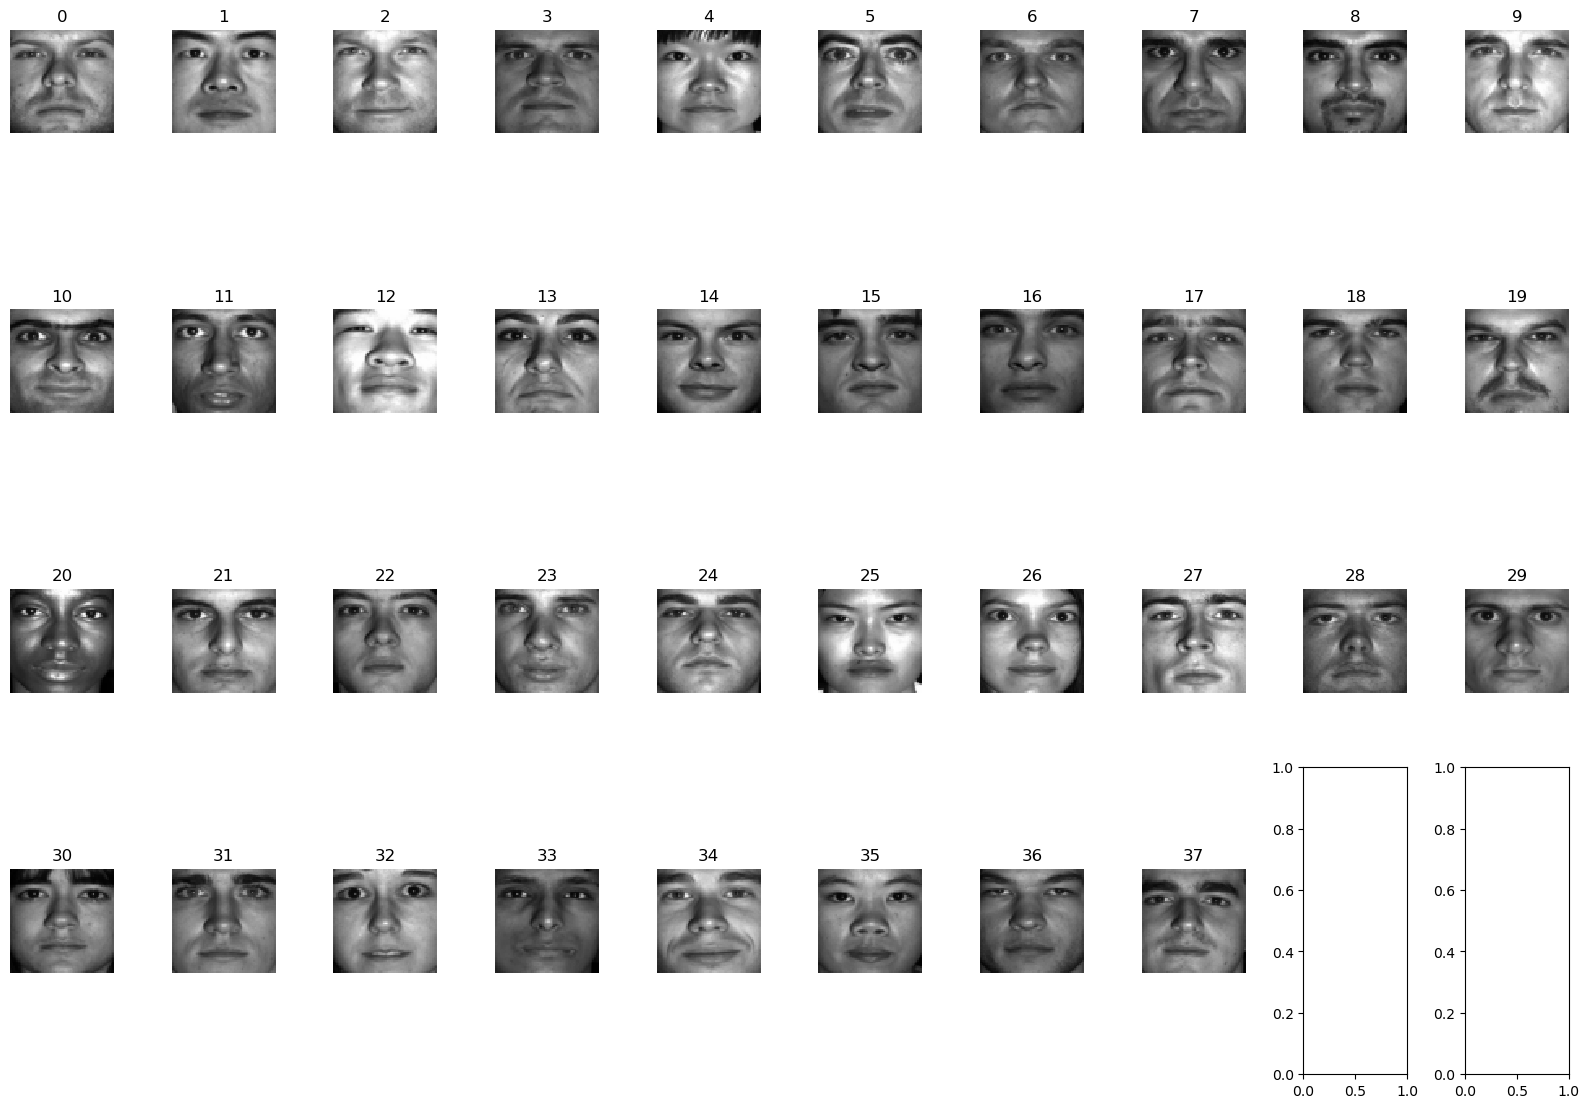

In [10]:
# visualize train samples
# 根据小样本学习设置显示不同的训练图像可视化
if FEW_SHOT == 1:
    # 小样本模式：显示所有训练样本（每个受试者只有一张图像）
    fig, ax = plt.subplots(4, 10, figsize=(16,12))  # 创建4行10列的子图
    ax = ax.ravel()  # 将子图轴展平为一维数组便于索引
    
    # 遍历所有训练样本
    for i in range(len(X_train)):
        ax[i].imshow(X_train[i], cmap='gray', vmax=1, vmin=0)  # 显示灰度图像，设置像素值范围0-1
        ax[i].set_title(str(Y_train[i]))  # 设置标题为对应的受试者ID
        ax[i].axis('off')  # 关闭坐标轴显示
    
    plt.tight_layout()  # 自动调整子图间距

else:
    # 正常模式：从每个受试者中随机选择一张图像显示
    fig, ax = plt.subplots(4, 10, figsize=(16,12))  # 创建4行10列的子图
    ax = ax.ravel()  # 将子图轴展平为一维数组便于索引
    
    # plot each subject
    # 为每个受试者绘制一张随机图像
    for i in range(N_SUBJECTS):
        # 从当前受试者的所有训练图像中随机选择一个索引
        pltIndex = np.random.randint(low=0, high=len(Y_train[Y_train == i]), size=1, dtype=int)[0]
        
        # 显示随机选择的图像
        ax[i].imshow(X_train[Y_train == i][pltIndex], cmap='gray', vmax=1, vmin=0)
        ax[i].set_title(str(Y_train[Y_train == i][pltIndex]))  # 设置标题为受试者ID
        ax[i].axis('off')  # 关闭坐标轴显示
    
    plt.tight_layout()  # 自动调整子图间距
    


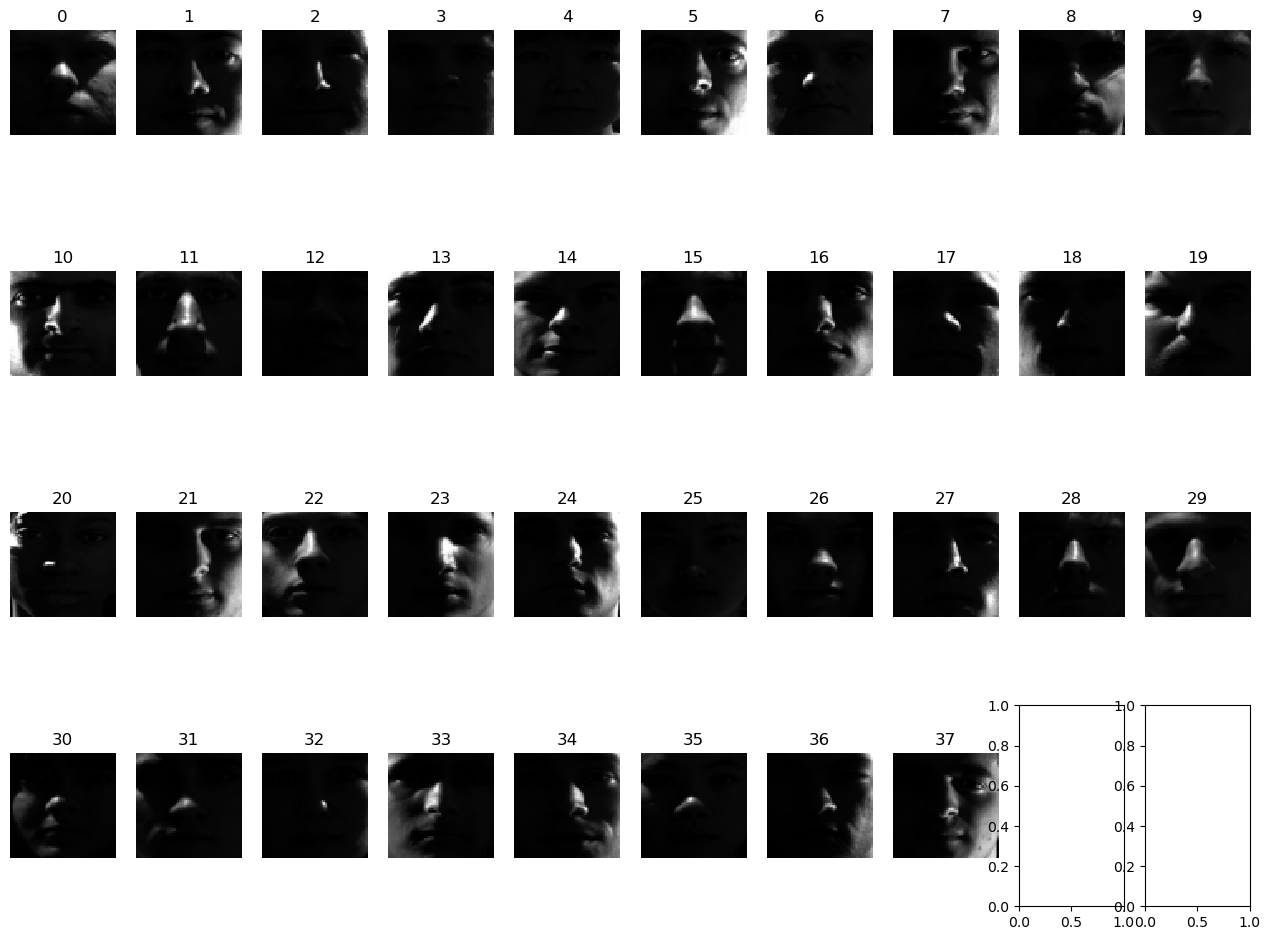

In [11]:
#可视化测试样本
fig, ax = plt.subplots(4, 10, figsize=(16,12))
ax = ax.ravel()  # 将子图轴对象展平为一维数组，便于循环访问

# 为每个受试者绘制一张随机测试图像
# plot each subject
for i in range(38):  # 遍历所有38个受试者
    # 从当前受试者i的所有测试图像中随机选择一个索引
    # Y_test == i 筛选出属于当前受试者的测试样本索引
    # np.random.randint 在有效范围内随机选择一个索引
    pltIndex = np.random.randint(low=0, high=len(Y_test[Y_test == i]), size=1, dtype=int)[0]
    
    # 显示随机选择的测试图像
    # X_test[Y_test == i][pltIndex] 获取当前受试者的第pltIndex张测试图像
    # cmap='gray' 使用灰度色彩映射，vmax=1, vmin=0 设置像素值显示范围为0-1
    ax[i].imshow(X_test[Y_test == i][pltIndex], cmap='gray', vmax=1, vmin=0)
    
    # 设置子图标题为对应的受试者ID
    ax[i].set_title(str(Y_test[Y_test == i][pltIndex]))
    
    # 关闭坐标轴显示，使图像更清晰
    ax[i].axis('off')
    #plt.tight_layout()

In [12]:
# show image information, RCDT-HOG information, y label information
#显示图像信息、RCDT-HOG信息、y标签信息
# 训练集形状信息：
# X_train.shape - 原始训练图像的形状：(样本数量, 图像高度, 图像宽度)
# X_rcdt_train.shape - RCDT特征训练数据的形状：(样本数量, 特征维度)
# Y_train.shape - 训练标签的形状：(样本数量,)
print(X_train.shape, X_rcdt_train.shape, Y_train.shape)

# 测试集形状信息：
# X_test.shape - 原始测试图像的形状：(样本数量, 图像高度, 图像宽度)
# X_rcdt_test.shape - RCDT特征测试数据的形状：(样本数量, 特征维度)
# Y_test.shape - 测试标签的形状：(样本数量,)
print(X_test.shape, X_rcdt_test.shape, Y_test.shape)


(38, 64, 64) (38, 21, 21, 16, 4) (38,)
(490, 64, 64) (490, 21, 21, 16, 4) (490,)


In [13]:
# Perform subspace learning
# training the NS classifiers
#执行子空间学习
#训练NS分类器
NS_clfs = [] # 存储所有NS分类器的列表
ROW_N = X_rcdt_train.shape[1]; COL_N = X_rcdt_train.shape[2]  # 获取RCDT特征的行数和列数（图像分块网格尺寸）

# if there are multiple traning samples, use cross-validation scheme to choose N_VAR as indicated in the paper
# otherwise choose N_VAR = 0.99
# 设置特征保留方差阈值：小样本模式使用0.99，正常模式使用0.8
N_VAR = 0.99 if FEW_SHOT == 1 else 0.8

# train NS subspace classifiers seperately
# 分别训练每个图像块的NS子空间分类器
for row_n in range(ROW_N):  # 遍历所有行块
    for col_n in range(COL_N):  # 遍历所有列块
        #print('row {}, col {}'.format(row_n,col_n))
        # 提取当前图像块的所有训练样本的RCDT特征
        X_train_temp = X_rcdt_train[:,row_n,col_n,:,:]
        X_train_temp_new = []
        # 将每个样本的当前块特征展平为一维向量
        for X_train_temp_each in X_train_temp:
            X_train_temp_new.append(X_train_temp_each.ravel())
        X_train_temp_new = np.asarray(X_train_temp_new)
        
        # 创建NS分类器实例，设置类别数、投影数和方差阈值
        clf_ns = NS(num_classes=N_SUBJECTS, num_proj=PROJECT_N, n_var=N_VAR)
        clf_ns.fit(X_train_temp_new, Y_train) # build V^c_k subspace for k'th Patch - 为第k个图像块构建V^c_k子空间
        NS_clfs.append(clf_ns)  # 将训练好的分类器添加到列表中

In [14]:
# perform testing
# 初始化测试输出矩阵：存储每个测试样本在每个图像块的NS分类器softmax输出
# 维度：[测试样本数, 行块数, 列块数, 类别数]
subspace_test_NS_output_softmax = np.zeros([len(X_rcdt_test), ROW_N, COL_N, N_SUBJECTS])
subject_cnt = 0  # 测试样本计数器

# 遍历每个测试样本的RCDT特征
for each_test_subject in X_rcdt_test:
    # 遍历每个图像块位置
    for row_n in range(ROW_N):
        for col_n in range(COL_N):
            # 提取当前测试样本在当前图像块的特征并展平
            each_test_subject_block = each_test_subject[row_n,col_n,:,:].ravel()
            each_test_subject_block = each_test_subject_block.reshape([1, len(each_test_subject_block)])
            
            # 使用对应的NS分类器进行预测
            # pred_vector_test: 预测向量，pred_test: 预测类别
            pred_vector_test, pred_test = NS_clfs[row_n*ROW_N+col_n].predict(each_test_subject_block)
            
            # compute d_k^c - 计算归一化的softmax输出（距离度量）
            # 对预测向量进行L2归一化，加上小常数防止除零
            subspace_test_NS_output_softmax[subject_cnt, row_n, col_n, : ] = pred_vector_test.ravel()/np.linalg.norm(pred_vector_test.ravel()+1e-5)

    subject_cnt = subject_cnt + 1  # 更新测试样本计数器

# 打印测试输出矩阵的形状
print(subspace_test_NS_output_softmax.shape)



(490, 21, 21, 38)


In [15]:
# calculate the classification accuracy
def get_acc(input_vectors_patch, input_y_test):
    # summing the distance contribution d^c_k and search c for the classification result
    # input shape: batch, height, width, features
    
    # 重新排列张量维度：从 [batch, height, width, features] 变为 [batch, features, (height * width)]
    # 将空间维度（height和width）展平，便于后续聚合
    input_vectors_patch_new = rearrange(input_vectors_patch, 'b h w f -> b f (h w) ')
    
    # 沿着展平的空间维度求和，聚合所有图像块的贡献
    # 得到形状为 [batch, features] 的聚合距离矩阵
    input_vectors_patch_new_aggre = np.sum(input_vectors_patch_new, axis=2)
    
    # 对每个测试样本，选择具有最小聚合距离的类别作为预测结果
    # 因为NS分类器输出的是距离度量，所以使用argmin
    y_pred_union = np.argmin(input_vectors_patch_new_aggre, axis=1)

    # 计算预测准确率：比较预测标签和真实标签
    return accuracy_score(y_pred_union, input_y_test)

# 调用函数计算并打印测试集分类准确率
print(get_acc(subspace_test_NS_output_softmax, Y_test))

0.9183673469387755
